# Notebook for computing scalar measures of non-normality

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '16'
os.environ['MKL_NUM_THREADS'] = '16'
os.environ['OPENBLAS_NUM_THREADS'] = '16'

# Compute energy-growth inputs and build reduced mass matrix (global + BCs applied)
import numpy as np
import scipy
from scipy import sparse
import h5py
from lin_ops_full_reduction import Matrix, build_reduction_mapping, make_global_mat
import matplotlib.pyplot as plt

In [2]:
# load the data
data = np.load('/mnt/homes/sfreiberger/research/recon_data/psc_data/harris_linear_20x6z/real_jacobian.npy')

In [3]:
# compute the scalar measures
frob_square = (np.linalg.norm(data, 'fro'))**2
print(f'Frobenius norm of the square: {frob_square}')
spectral_square = (np.linalg.norm(data, 2))**2
print(f'Spectral norm of the square: {spectral_square}')
diff = (np.conj(data).T @ data) - (data @ np.conj(data).T)
frobenius_norm = np.linalg.norm(diff, 'fro')/frob_square
spectral_norm = np.linalg.norm(diff, 2)/spectral_square
print(f'Frobenius norm: {frobenius_norm}')
print(f'Spectral norm: {spectral_norm}')

Frobenius norm of the square: 1.447146581929284e+35
Spectral norm of the square: 2.1769038305942694e+32
Frobenius norm: 0.04218366792879736
Spectral norm: 1.0000000000000009


In [72]:
data_dir = '/mnt/homes/sfreiberger/research/recon_data/psc_data/harris_linear_20x6z'
massmat_path = f'{data_dir}/mass_mat.h5'
jacobian_path = f'{data_dir}/lin_ops.h5'

# keep_global includes both field-block selection and BC filtering
nr_local, keep_global = build_reduction_mapping(jacobian_path)

mass_local = Matrix(massmat_path, '/massmat')
jac = Matrix(jacobian_path, '/jacobian')

# Expand scalar mass matrix to the 7-field global state and map to global indexing
mmat_big = scipy.sparse.block_diag([mass_local.csr_rep] * 7, format='csr')
mmat_gl = make_global_mat(mmat_big.toarray(), nrg=jac.nrg, ncg=jac.ncg, lg=jac.lg)
mmat_gl = sparse.csr_array(mmat_gl)
mmat_gl.eliminate_zeros()

# Reduced mass matrix with global assembly and boundary conditions applied
reduced_mmat = mmat_gl[keep_global][:, keep_global].tocsr()

nrg_block = jac.nrg // 7
#slice upper left 3x3 blocks to get the mass matrix for the velocity fields only
reduced_mmat_3x3 = reduced_mmat[:3*nrg_block, :3*nrg_block]


In [88]:

vec_arr = []
for i in range(0, 8000, 10):
    with h5py.File(f'{data_dir}/data/xmhd2d_{i:05d}.rst', 'r') as f:
        vx = np.array(f['U_velx'][:])
        vy = np.array(f['U_vely'][:])
        vz = np.array(f['U_velz'][:])
        vec_arr.append(np.concatenate([vx.ravel(), vy.ravel(), vz.ravel()]))
        
states = np.array([vec.T@reduced_mmat_3x3@vec for vec in vec_arr])

e = states/2


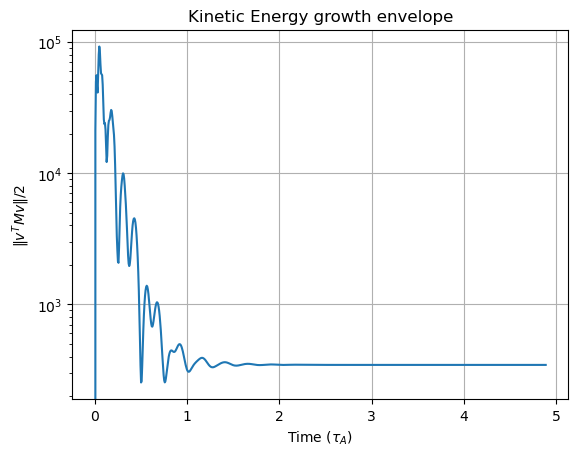

Global mass matrix shape: (15540, 15540)
Reduced mass matrix shape: (10500, 10500)


In [92]:

#plot the energy gdrowth envelope
dt = 1e-7/0.00001634796
t = np.arange(0, len(states)*dt, dt)
plt.plot(t, e)
plt.yscale('log')
plt.xlabel(r'Time ($\tau_A$)')
plt.ylabel(r'$\|v^TMv\|/2$')
plt.title('Kinetic Energy growth envelope')
plt.grid()  
plt.show()
    
print(f'Global mass matrix shape: {mmat_gl.shape}')
print(f'Reduced mass matrix shape: {reduced_mmat.shape}')